<a href="https://colab.research.google.com/github/lledson425/Summer25/blob/main/VAE_and_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import sys
import numpy as np
from thesis_ml.ising_vae import VAE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sklearn.cluster as skl_cluster
from sklearn import manifold, decomposition, datasets
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.cluster import SpectralClustering
import statistics

2025-07-29 14:37:27.360386: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-29 14:37:27.408566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753814247.439833 2633564 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753814247.448455 2633564 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753814247.472976 2633564 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [57]:
data_dir = "training16"
MAX_FILES = 25000  # < LIMIT the number of files to read

# Get sorted list of all files, filtered to actual files
file_list = sorted([f for f in os.listdir(data_dir)
                    if os.path.isfile(os.path.join(data_dir, f))])

# Limit to max N files
file_list = file_list[:MAX_FILES]

# Initialize data storage
data = []

# Load data from files (up to MAX_FILES)
for file_name in file_list:
    with open(os.path.join(data_dir, file_name), 'r') as f:
        for line in f:
            try:
                values = [int(x) for x in line.strip().split()]
                data.append(values)
            except ValueError:
                print(f"Skipping corrupted line in {file_name}: {line!r}")
                continue

data = np.array(data)

np.save("data.npy", data)

print(f"Loaded data from {len(file_list)} files.")
print("Total size of data array:", data.size)
print(data)


FileNotFoundError: [Errno 2] No such file or directory: 'training16'

In [2]:
data = np.load("data.npy")

In [3]:
print("Raw shape:", data.shape)
side = int(data.shape[1]**0.5)
print("Inferred side length:", side)

Raw shape: (18500, 65536)
Inferred side length: 256


In [4]:
#VAE expect images so we need to unflatten the data
flat_data = data
side_length = int(data.shape[1]**0.5)
data = data.reshape(-1, side_length, side_length)  # Shape: (4000, 32, 32)
# np.savetxt("ising_dataset.txt", data.reshape(data.shape[0], -1), delimiter=',')
print(data)
print(data.size)

[[[ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]
  ...
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]
  [ 1  1  1 ...  1  1  1]]

 [[-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]
  ...
  [-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]]

 [[-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]
  ...
  [-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]
  [-1 -1 -1 ... -1 -1 -1]]

 ...

 [[ 1  1  1 ...  1  1  1]
  [ 1 -1 -1 ... -1 -1 -1]
  [ 1  1  1 ... -1 -1 -1]
  ...
  [ 1 -1 -1 ... -1  1  1]
  [ 1  1 -1 ... -1  1  1]
  [ 1  1  1 ...  1  1  1]]

 [[-1 -1 -1 ...  1  1 -1]
  [ 1  1  1 ...  1  1 -1]
  [ 1 -1  1 ...  1  1  1]
  ...
  [ 1 -1 -1 ... -1  1 -1]
  [-1 -1 -1 ...  1  1 -1]
  [-1 -1 -1 ...  1  1 -1]]

 [[ 1 -1 -1 ...  1  1  1]
  [-1  1  1 ...  1  1 -1]
  [-1  1 -1 ...  1  1 -1]
  ...
  [ 1  1  1 ...  1 -1  1]
  [ 1 -1 -1 ... -1 -1  1]
  [ 1 -1 -1 ... -1 -1 -1]]]
1212416000

In [5]:
print("Raw shape:", data.shape)

Raw shape: (18500, 256, 256)


In [6]:
split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

# Train VAE
vae = VAE(train_images=train_data, test_images=test_data, epochs=25, batch_size=16)
vae.saveModel("new256.3.keras")

Epoch: 25, Test set ELBO: -29016.0449, time elapse for current epoch: 201.27s


/home/lledson/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [66]:
model_path = "new16.2.keras"
vae = VAE(load=model_path)

/home/lledson/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


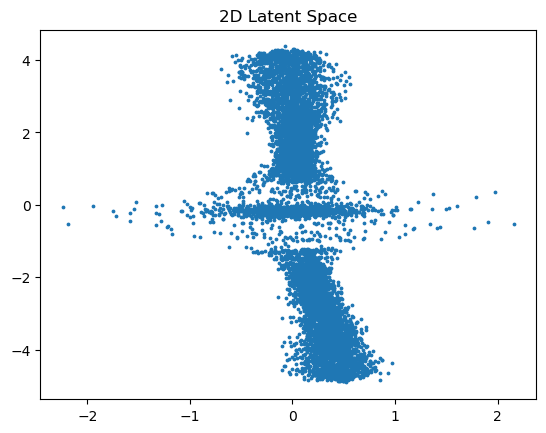

In [7]:
batch_size = 128
means_list = []
logvars_list = []

for i in range(0, len(data), batch_size):
    batch = data[i:i + batch_size]
    m, l = vae.encode(batch, both=True)
    means_list.append(m)
    logvars_list.append(l)

means = np.concatenate(means_list, axis=0)
logvars = np.concatenate(logvars_list, axis=0)

# np.save("latent_means_final32.1.npy", means)
# np.save("latent_logvars_final32.1.npy", logvars)

# Plot the 2D latent space
plt.scatter(means[:, 0], means[:, 1], s=3)
plt.title("2D Latent Space")
plt.show()

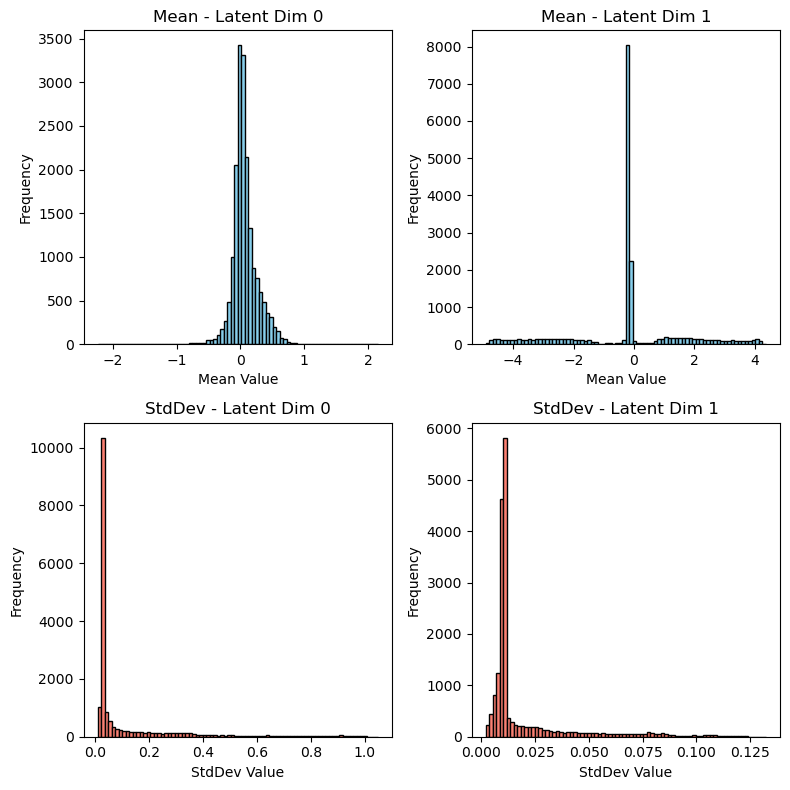

In [8]:

# Convert log-variances to standard deviations
stddevs = np.exp(logvars / 2.0)

latent_dim = means.shape[1]  # Automatically infer latent dimension

# Plot per-dimension histograms
fig, axes = plt.subplots(2, latent_dim, figsize=(4 * latent_dim, 8))

for i in range(latent_dim):
    # Mean histogram
    axes[0, i].hist(means[:, i], bins=80, color='skyblue', edgecolor='black')
    axes[0, i].set_title(f"Mean - Latent Dim {i}")
    axes[0, i].set_xlabel("Mean Value")
    axes[0, i].set_ylabel("Frequency")

    # Stddev histogram
    axes[1, i].hist(stddevs[:, i], bins=80, color='salmon', edgecolor='black')
    axes[1, i].set_title(f"StdDev - Latent Dim {i}")
    axes[1, i].set_xlabel("StdDev Value")
    axes[1, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


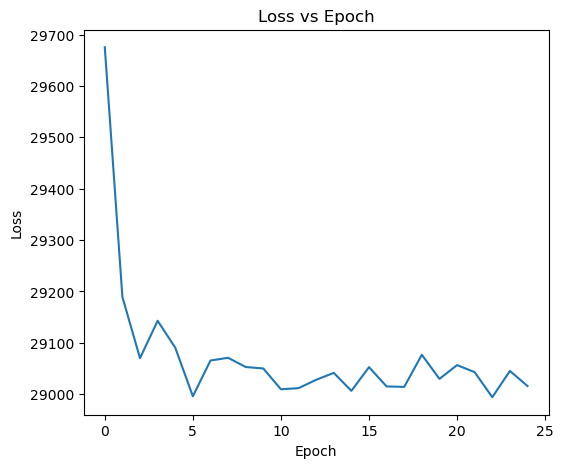

In [9]:
vae.plot_loss()
variances = np.exp(logvars)

In [7]:
temperature_list = [
    0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
    1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9,
    2.0, 2.01, 2.02, 2.03, 2.04, 2.05, 2.06, 2.07, 2.08, 2.09,
    2.1, 2.11, 2.12, 2.13, 2.14, 2.15, 2.16, 2.17, 2.18, 2.19,
    2.2, 2.21, 2.22, 2.23, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29,
    2.3, 2.31, 2.32, 2.33, 2.34, 2.35, 2.36, 2.37, 2.38, 2.39,
    2.4, 2.41, 2.42, 2.43, 2.44, 2.45, 2.46, 2.47, 2.48, 2.49,
    2.5, 2.51, 2.52, 2.53, 2.54, 2.55, 2.56, 2.57, 2.58, 2.59,
    2.6,
    2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5,
    3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5,
    4.6, 4.7, 4.8, 4.9, 5.0
]


In [11]:
temperature_list = [
    1.725,1.74143803,1.75787606,1.77431409,1.79075211,1.80719014,1.82362817,1.8400662,1.85650423,1.87294226,
    1.88938028,1.90581831,1.92225634,1.93869437,1.9551324,1.97157042,1.98800845,2.00444648,2.02088451,
    2.03732254,2.05376056,2.07019859,2.08663662,2.10307465,2.11951268,2.1359507,2.15238873,2.16882676,
    2.18526479,2.20170282,2.21814084,2.23457887,2.2510169,2.26745493,2.28389296,2.30033098,2.31676901,
    2.33320704,2.34964507,2.3660831,2.38252112,2.39895915,2.41539718,2.43183521,2.44827324,2.46471126,
    2.48114929,2.49758732,2.51402535,2.53046338,2.5469014,2.56333943,2.57977746,2.59621549,2.61265352,
    2.62909154,2.64552957,2.6619676,2.67840563,2.69484366,2.71128168,2.72771971,2.74415774,2.76059577,
    2.7770338,2.79347182,2.80990985,2.82634788,2.84278591,2.85922394,2.87566196
]
print(len(temperature_list))


71


In [7]:
temperature_list = [
    1.725,1.74143803,1.75787606,1.77431409,1.79075211,1.80719014,1.82362817,1.8400662,1.85650423,1.87294226,
    1.88938028,1.90581831,1.92225634,1.93869437,1.9551324,1.97157042,1.98800845,2.00444648,2.02088451,
    2.03732254,2.05376056,2.07019859,2.08663662,2.10307465,2.11951268,2.1359507,2.15238873,2.16882676,
    2.18526479,2.20170282,2.21814084,2.23457887,2.2510169,2.26745493,2.28389296,2.30033098,2.31676901,
    2.33320704,2.34964507,2.3660831,2.38252112,2.39895915,2.41539718,2.43183521,2.44827324,2.46471126,
    2.48114929,2.49758732,2.51402535,2.53046338,2.5469014,2.56333943,2.57977746,2.59621549,2.61265352,
    2.62909154,2.64552957,2.6619676,2.67840563,2.69484366,2.71128168,2.72771971,2.74415774,2.76059577,
    2.7770338,2.79347182,2.80990985,2.82634788,2.84278591,2.85922394,2.87566196, 2.89209999,2.90853802,
    2.92497604,2.94141407,2.95785210,2.97429013,2.99072815,3.00716618,3.02360421,3.04004224,3.05648027,
    3.07291829,3.08935632,3.10579435,3.12223238,3.13867040,3.15510843,3.17154646,3.18798449,3.20442252,
    3.22086054,3.23729857,3.25373660,3.27017463,3.28661265,3.30305068,3.31948871,3.33592674,3.35236477,
    3.36880279,3.38524082,3.40167885
]
print(len(temperature_list))

103


In [12]:
temperature_list = [1.7,1.72264151,1.74528302,1.76792453,1.79056604,1.81320755,1.83584906,1.85849057,
                    1.88113208,1.90377358,1.92641509,1.9490566,1.97169811,1.99433962,2.01698113,
                    2.03962264,2.06226415,2.08490566,2.10754717,2.13018868,2.15283019,2.1754717,
                    2.19811321,2.22075472,2.24339623,2.26603774,2.28867925,2.31132075,2.33396226,
                    2.35660377,2.37924528,2.40188679,2.4245283,2.44716981,2.46981132,2.49245283,
                    2.51509434,2.53773585,2.56037736,2.58301887,2.60566038,2.62830189,2.6509434,
                    2.67358491,2.69622642,2.71886792,2.74150943,2.76415094,2.78679245,2.80943396,
                    2.83207547,2.85471698,2.87735849,2.9]
print(len(temperature_list))

54


In [14]:
temperature_list = [2.050, 2.065, 2.080, 2.095, 2.110, 2.125, 2.140, 2.155, 2.170, 2.185, 2.200, 2.215, 
                    2.230, 2.245, 2.260, 2.275, 2.290, 2.305, 2.320, 2.335, 2.350, 2.365, 2.380, 2.395, 
                    2.410, 2.425, 2.440, 2.455, 2.470, 2.485, 2.500, 2.515, 2.530, 2.545, 2.560, 2.575, 
                    2.590, 2.605, 2.620, 2.635, 2.650, 2.665, 2.680, 2.695, 2.710, 2.725, 2.740, 2.755, 
                    2.770, 2.785]
print(len(temperature_list))

50


In [14]:
temperature_list = [1.0, 1.04109589, 1.08219178, 1.12328767, 1.16438356, 1.20547945, 1.24657534, 1.28767123, 1.32876712, 1.36986301,
 1.4109589, 1.45205479, 1.49315068, 1.53424658, 1.57534247, 1.61643836, 1.65753425, 1.69863014, 1.73972603, 1.78082192,
 1.82191781, 1.8630137, 1.90410959, 1.94520548, 1.98630137, 2.02739726, 2.06849315, 2.10958904, 2.15068493, 2.19178082,
 2.23287671, 2.2739726, 2.31506849, 2.35616438, 2.39726027, 2.43835616, 2.47945205, 2.52054795, 2.56164384, 2.60273973,
 2.64383562, 2.68493151, 2.7260274, 2.76712329, 2.80821918, 2.84931507, 2.89041096, 2.93150685, 2.97260274, 3.01369863,
 3.05479452, 3.09589041, 3.1369863, 3.17808219, 3.21917808, 3.26027397, 3.30136986, 3.34246575, 3.38356164, 3.42465753,
 3.46575342, 3.50684932, 3.54794521, 3.5890411, 3.63013699, 3.67123288, 3.71232877, 3.75342466, 3.79452055, 3.83561644,
 3.87671233, 3.91780822, 3.95890411, 4.0]
print(len(temperature_list))


74


In [10]:
#temp list for 128x128

temperature_list = [ 2.2310, 2.2338, 2.2366, 2.2395, 2.2423, 2.2451, 2.2480, 2.2508, 2.2536, 2.2565,
2.2593, 2.2621, 2.2650, 2.2678, 2.2706, 2.2735, 2.2763, 2.2791, 2.2820, 2.2848,
2.2876, 2.2905, 2.2933, 2.2961, 2.2990, 2.3018, 2.3046, 2.3075, 2.3103, 2.3131,
2.3160, 2.3188, 2.3216, 2.3245, 2.3273, 2.3301, 2.3330, 2.3358, 2.3386, 2.3415,
2.3443, 2.3471, 2.3500, 2.3528, 2.3556, 2.3585, 2.3613, 2.3641, 2.3670, 2.3690
]
print(len(temperature_list))

50


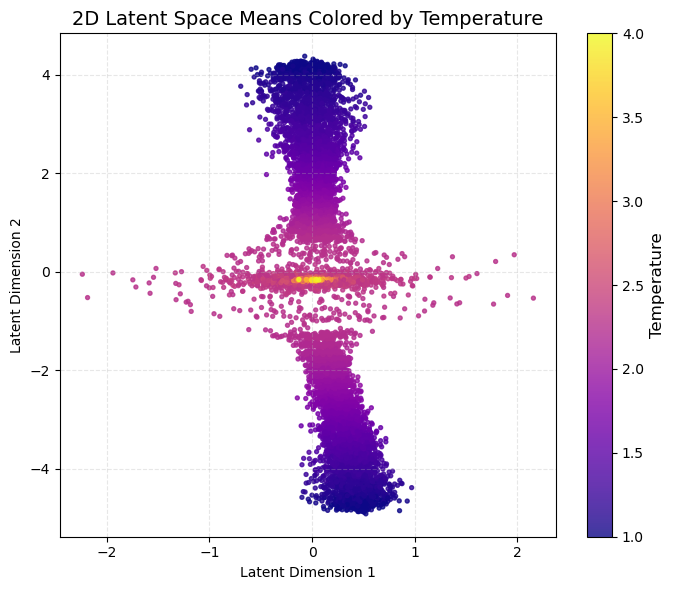

In [15]:

# temperature_list = [0.01, 0.14, 0.27, 0.40, 0.53, 0.66, 0.79, 0.92, 1.05, 1.18,
#                     1.31, 1.44, 1.57, 1.70, 1.83, 1.96, 2.09, 2.22, 2.35, 2.48,
#                     2.61, 2.74, 2.87, 3.00, 3.13, 3.26, 3.39, 3.52, 3.65, 3.78,
#                     3.91, 4.04, 4.17, 4.30, 4.43, 4.56, 4.69, 4.82, 4.95, 5.00]

temperature_labels = temperature_list * (len(means) // len(temperature_list))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(means)
pca_result = means 

plt.figure(figsize=(7, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=temperature_labels, cmap='plasma', s=8, alpha=0.8)
cbar = plt.colorbar(scatter)
cbar.set_label("Temperature", fontsize=12)

plt.title("2D Latent Space Means Colored by Temperature", fontsize=14)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


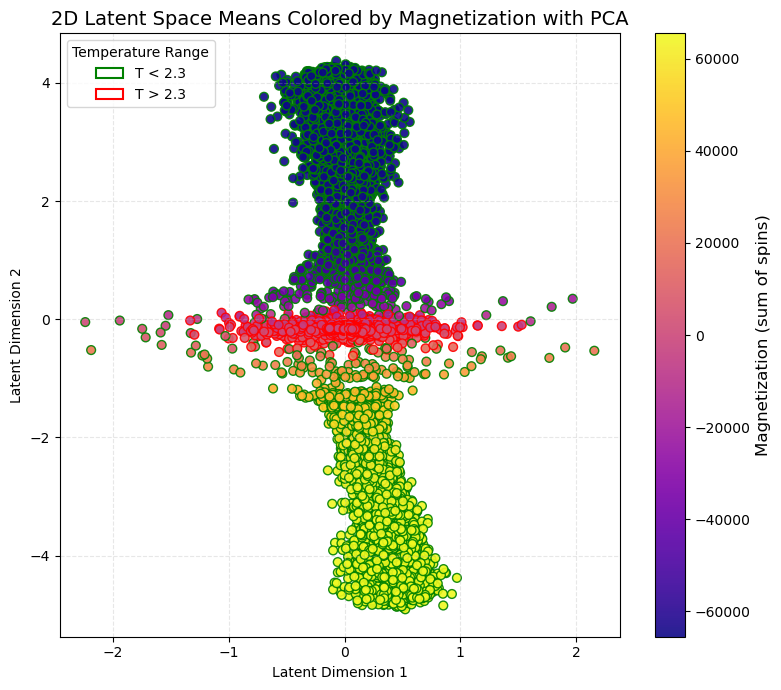

In [16]:
import matplotlib.patches as mpatches

# Compute magnetization = sum of spins per config
magnetizations = np.sum(flat_data, axis=1)

# Assign temperature labels
temperature_labels = temperature_list * (len(means) // len(temperature_list))
temperature_labels = np.array(temperature_labels)

# labels_combined = np.column_stack([temperature_labels, magnetizations])
# np.save("temperature_and_magnetization_final16.4.npy", labels_combined)


# Color outline: green if T > 2.3, blue otherwise
outline_colors = np.where(temperature_labels > 2.3, 'red', 'green')

# Plot
plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    pca_result[:, 0], pca_result[:, 1],
    c=magnetizations,
    cmap='plasma',
    edgecolors=outline_colors,
    linewidths=1.0,
    s=40,
    alpha=0.9,
)

legend_patches = [
    mpatches.Patch(edgecolor='green', facecolor='white', label='T < 2.3', linewidth=1.5),
    mpatches.Patch(edgecolor='red', facecolor='white', label='T > 2.3', linewidth=1.5),
]
plt.legend(handles=legend_patches, loc='upper left', title='Temperature Range')


cbar = plt.colorbar(scatter)
cbar.set_label("Magnetization (sum of spins)", fontsize=12)

plt.title("2D Latent Space Means Colored by Magnetization with PCA", fontsize=14)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
latent_dim = variances.shape[1]
fig, axes = plt.subplots(latent_dim, 1, figsize=(6, 3 * latent_dim))

for i in range(latent_dim):
    ax = axes[i] if latent_dim > 1 else axes
    ax.hist(variances[:, i], bins=40, alpha=0.8)
    ax.set_title(f"Variance Distribution for Latent Dimension {i}")
    ax.set_xlabel("Variance")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

NameError: name 'variances' is not defined

In [ ]:
sample_idx = 0
plt.bar(range(latent_dim), variances[sample_idx])
plt.xlabel("Latent Dimension")
plt.ylabel("Variance")
plt.title(f"Variance in Latent Space for Sample {sample_idx}")
plt.show()

NameError: name 'latent_dim' is not defined

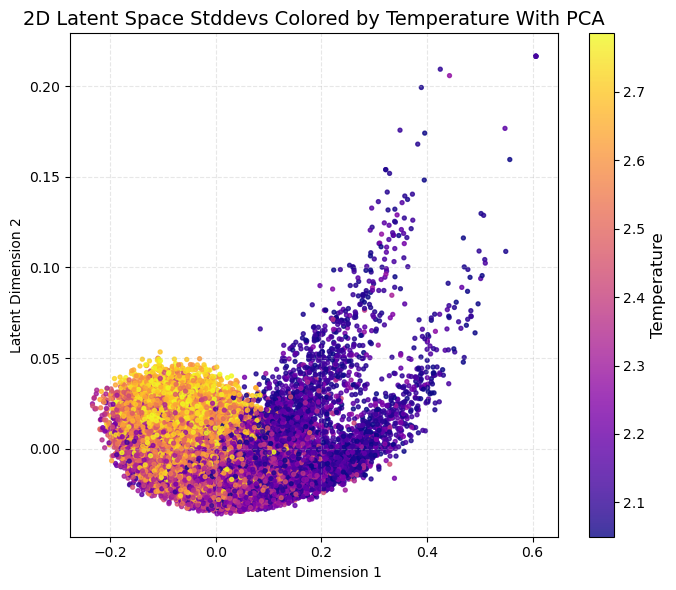

In [72]:
stddevs = np.exp(logvars)**0.5

# temperature_list = [0.01, 0.14, 0.27, 0.40, 0.53, 0.66, 0.79, 0.92, 1.05, 1.18,
#                     1.31, 1.44, 1.57, 1.70, 1.83, 1.96, 2.09, 2.22, 2.35, 2.48,
#                     2.61, 2.74, 2.87, 3.00, 3.13, 3.26, 3.39, 3.52, 3.65, 3.78,
#                     3.91, 4.04, 4.17, 4.30, 4.43, 4.56, 4.69, 4.82, 4.95, 5.00]

temperature_labels = temperature_list * (len(stddevs) // len(temperature_list))

# PCA on standard deviations
pca = PCA(n_components=2)
pca_result_std = pca.fit_transform(stddevs)

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(pca_result_std[:, 0], pca_result_std[:, 1], c=temperature_labels, cmap='plasma', s=8, alpha=0.8)
cbar = plt.colorbar(scatter)
cbar.set_label("Temperature", fontsize=12)

plt.title("2D Latent Space Stddevs Colored by Temperature With PCA", fontsize=14)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

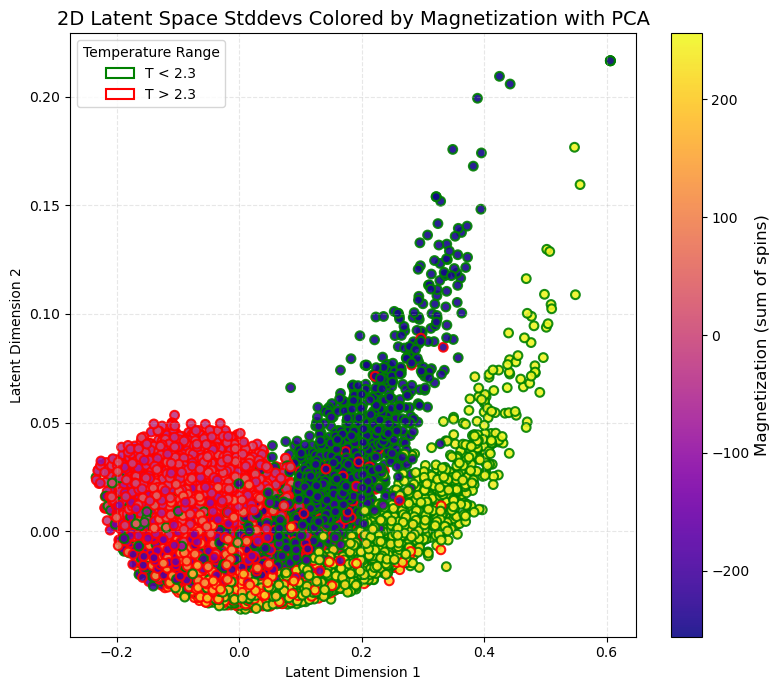

In [73]:

# Compute magnetization = sum of spins per configuration
magnetizations = np.sum(flat_data, axis=1)

# Assign temperature labels (make sure sizes match)
temperature_labels = temperature_list * (len(stddevs) // len(temperature_list))
temperature_labels = np.array(temperature_labels)

# Outline color by temperature: red if T > 2.3, green otherwise
outline_colors = np.where(temperature_labels > 2.3, 'red', 'green')

# Plot
plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    pca_result_std[:, 0], pca_result_std[:, 1],
    c=magnetizations,
    cmap='plasma',
    edgecolors=outline_colors,
    linewidths=1.5,
    s=40,
    alpha=0.9,
)

# Legend for outlines
legend_patches = [
    mpatches.Patch(edgecolor='green', facecolor='white', label='T < 2.3', linewidth=1.5),
    mpatches.Patch(edgecolor='red', facecolor='white', label='T > 2.3', linewidth=1.5),
]
plt.legend(handles=legend_patches, loc='upper left', title='Temperature Range')

# Colorbar for magnetization
cbar = plt.colorbar(scatter)
cbar.set_label("Magnetization (sum of spins)", fontsize=12)

# Labels and formatting
plt.title("2D Latent Space Stddevs Colored by Magnetization with PCA", fontsize=14)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

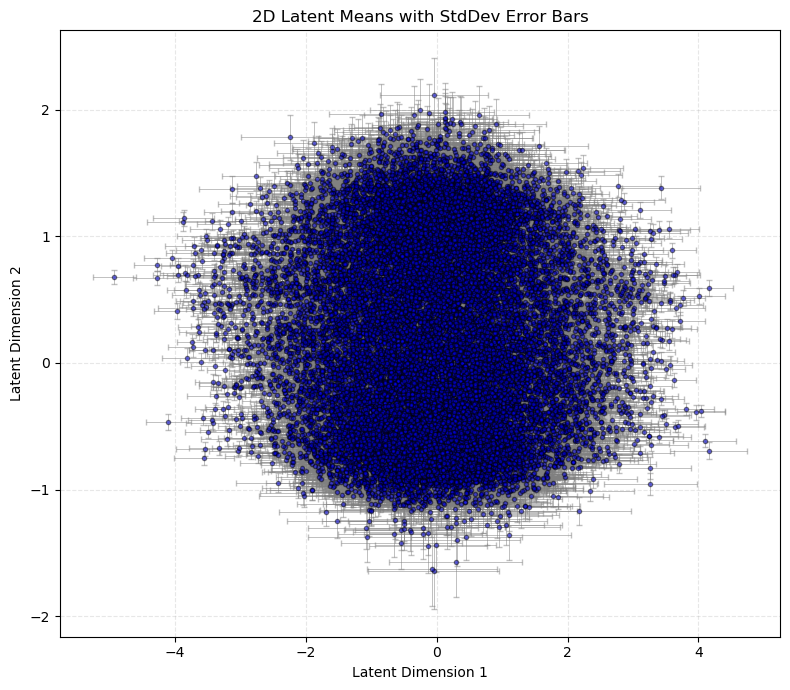

In [13]:
plt.figure(figsize=(8, 7))

# Plot points with error bars
plt.errorbar(
    means[:, 0], means[:, 1],
    xerr=stddevs[:, 0], yerr=stddevs[:, 1],
    fmt='o', ecolor='gray', elinewidth=0.7, capsize=2, alpha=0.5,
    markerfacecolor='blue', markeredgecolor='black', markersize=3, linestyle='none'
)

# Labels and title
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Means with StdDev Error Bars")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


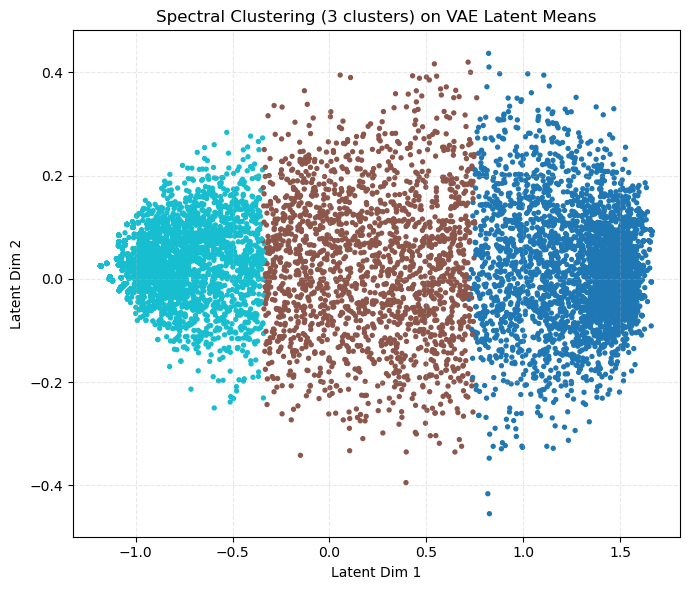

In [27]:
clusters = np.loadtxt("vae_clusters_focused8.4.csv", delimiter=",", dtype=int)
fitImgsVAE = vae.encode(data)
fitImgsSTD = np.exp(vae.encode(data, mean = False))**0.5

plt.figure(figsize=(7,6))
plt.scatter(fitImgsVAE[:, 0], fitImgsVAE[:, 1], c=clusters, cmap='tab10', s=8)
plt.title("Spectral Clustering (3 clusters) on VAE Latent Means")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
fitImgsVAE = means
fitImgsSTD = np.exp(logvars)**0.5
fitImgsVAE = fitImgsVAE.astype(np.float32)
fitImgsSTD = fitImgsSTD.astype(np.float32)

def compute_overlap_matrix(mu, sigma):
    mu = mu.astype(np.float32)
    sigma = sigma.astype(np.float32)

    mu_i = mu[:, None]
    mu_j = mu[None, :]
    sigma_i = sigma[:, None]
    sigma_j = sigma[None, :]

    sigma_sq_sum = sigma_i**2 + sigma_j**2
    coef = (2 * sigma_i * sigma_j) / sigma_sq_sum
    exponent = -((mu_i - mu_j)**2) / (4 * sigma_sq_sum)
    return (coef * np.exp(exponent)).astype(np.float32)


# Compute 2D product overlap
overlap1 = compute_overlap_matrix(fitImgsVAE[:, 0], fitImgsSTD[:, 0])
overlap2 = compute_overlap_matrix(fitImgsVAE[:, 1], fitImgsSTD[:, 1])
overlap = overlap1 * overlap2

np.save("overlap_matrix_final16.4.npy", overlap)


def build_knn_affinity(overlap, k=10):
    N = overlap.shape[0]
    knn = np.zeros_like(overlap)
    for i in range(N):
        top_k = np.argsort(overlap[i])[-(k+1):]  # include self
        knn[i, top_k] = overlap[i, top_k]
    # Ensure symmetry
    knn = np.maximum(knn, knn.T)
    return knn

# # Add small value only to zero entries to avoid disconnected graph
# epsilon = 1e-8
# overlap[overlap == 0] = epsilon

# import seaborn as sns
# sns.heatmap(overlap, cmap='viridis')
# plt.title("Latent Gaussian Overlap Matrix")
# plt.show()



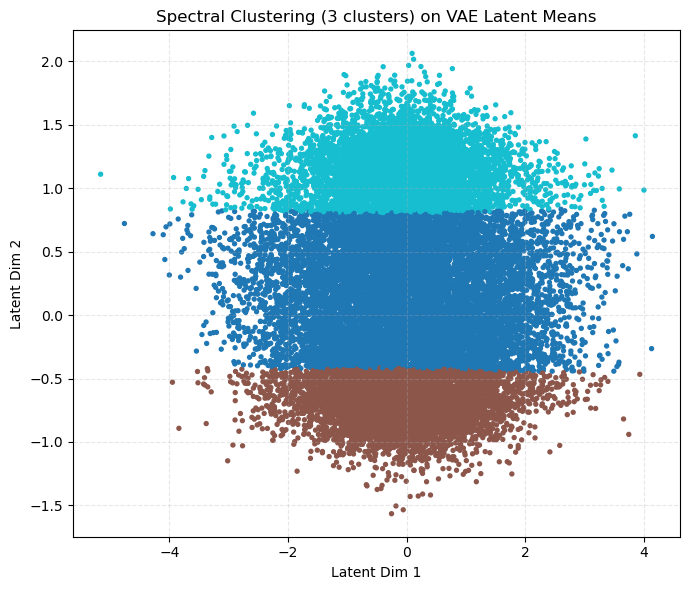

In [55]:
clusters = SpectralClustering(
    n_clusters=3,
    affinity='precomputed',
    eigen_solver='arpack',
    eigen_tol=0,
    random_state=42
).fit_predict(overlap)


plt.figure(figsize=(7,6))
plt.scatter(fitImgsVAE[:, 0], fitImgsVAE[:, 1], c=clusters, cmap='tab10', s=8)
plt.title("Spectral Clustering (3 clusters) on VAE Latent Means")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
np.savetxt("final_clusters16.4.csv", clusters, delimiter=",", fmt="%d")

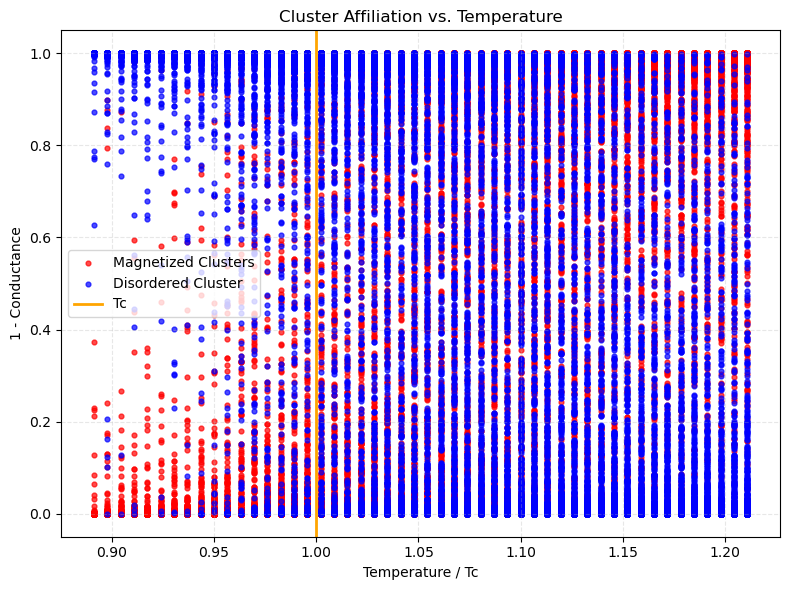

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# - Configuration -
Tc = 2.3
use_combined = False  # < Toggle between combined or current clusters

# - Inputs -
if use_combined:
    temps = np.array(combined_temp_mag[:, 0])
    temps_scaled = temps / Tc
    n = len(temps)
else:
    temps = np.array(temperature_labels)
    temps_scaled = temps / Tc
    n = len(temps)

# Choose cluster assignment
if use_combined:
    clusters_to_use = combined_clusters
else:
    clusters_to_use = clusters  # assumed defined elsewhere

# - Define Clusters -
magnetized_clusters = {2, 1}
disordered_cluster = list(set(clusters_to_use) - magnetized_clusters)[0]

# - Conductance Score Function -
def compute_conductance(overlap, clusters, target_cluster, eps=1e-12):
    scores = []
    for i in range(overlap.shape[0]):
        cluster_mask = (clusters == target_cluster)
        same_cluster = overlap[i, cluster_mask]
        all_total = np.sum(overlap[i])
        score = np.sum(same_cluster) / (all_total + eps)
        scores.append(score)
    return np.array(scores)

# - Compute Scores -
# Magnetized = sum of conductance to both clusters
magnetized_score = sum(
    compute_conductance(overlap, clusters_to_use, c)
    for c in magnetized_clusters
)

# Disordered
disordered_score = compute_conductance(overlap, clusters_to_use, disordered_cluster)

# - Save Results -
output_array = np.column_stack([
    temps_scaled,
    1 - magnetized_score,
    1 - disordered_score
])

np.savetxt("conductance_scores_final16.4.csv", output_array,
           delimiter=",",
           header="Temp_Scaled,1-Magnetized_Score,1-Disordered_Score",
           comments='',
           fmt="%.4f,%.6f,%.6f")

# - Plot -
plt.figure(figsize=(8, 6))
plt.scatter(temps_scaled, 1 - magnetized_score, color='red', s=12, alpha=0.7, label='Magnetized Clusters')
plt.scatter(temps_scaled, 1 - disordered_score, color='blue', s=12, alpha=0.7, label='Disordered Cluster')
plt.axvline(1.0, color='orange', linewidth=2, label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title("Cluster Affiliation vs. Temperature")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()



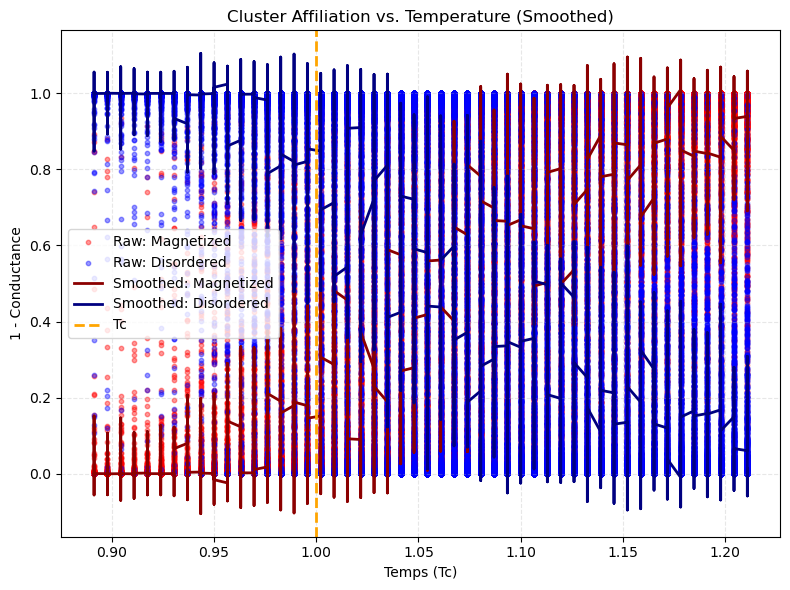

In [18]:
from scipy.signal import savgol_filter

sorted_indices = np.argsort(temps_scaled)
temps_sorted = temps_scaled[sorted_indices]
magnetized_sorted = (1 - magnetized_score)[sorted_indices]
disordered_sorted = (1 - disordered_score)[sorted_indices]

# Apply Savitzky-Golay smoothing
# window_length must be odd and < len(data); polyorder=2 for trend-preserving
window = 21 if len(temps_sorted) >= 21 else (len(temps_sorted) // 2) * 2 + 1
mag_smooth = savgol_filter(magnetized_sorted, window_length=window, polyorder=3)
dis_smooth = savgol_filter(disordered_sorted, window_length=window, polyorder=3)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(temps_sorted, magnetized_sorted, color='red', s=10, alpha=0.4, label='Raw: Magnetized')
plt.scatter(temps_sorted, disordered_sorted, color='blue', s=10, alpha=0.4, label='Raw: Disordered')
plt.plot(temps_sorted, mag_smooth, color='darkred', linewidth=2, label='Smoothed: Magnetized')
plt.plot(temps_sorted, dis_smooth, color='navy', linewidth=2, label='Smoothed: Disordered')
plt.axvline(1.0, color='orange', linewidth=2, linestyle='--', label='Tc')

plt.xlabel("Temps (Tc)")
plt.ylabel("1 - Conductance")
plt.title("Cluster Affiliation vs. Temperature (Smoothed)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

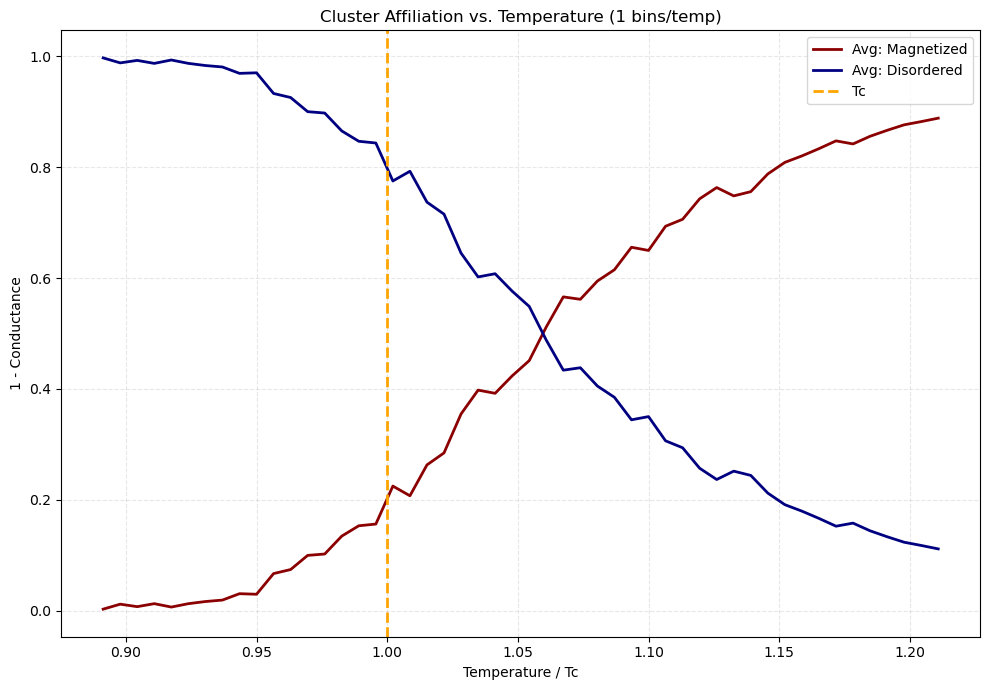

In [60]:
# Configurable multiplier: how many bins per temperature
bins_per_temp = 1  # e.g., 3 bins per temperature

# Compute 1 - conductance
magnetized_vals = 1 - magnetized_score
disordered_vals = 1 - disordered_score

# Unique temperatures
unique_temps = np.unique(temps)
binned_temp = []
binned_mag = []
binned_dis = []

for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]
    
    # Shuffle to randomize 
    np.random.shuffle(indices)
    
    # Split into sub-bins
    sub_bins = np.array_split(indices, bins_per_temp)
    
    for sub in sub_bins:
        if len(sub) > 0:
            binned_temp.append(T / Tc)
            binned_mag.append(np.mean(magnetized_vals[sub]))
            binned_dis.append(np.mean(disordered_vals[sub]))

binned_temp = np.array(binned_temp)
binned_mag = np.array(binned_mag)
binned_dis = np.array(binned_dis)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(binned_temp, binned_mag, color='darkred', linewidth=2, label='Avg: Magnetized')
plt.plot(binned_temp, binned_dis, color='navy', linewidth=2, label='Avg: Disordered')

plt.axvline(1.0, color='orange', linewidth=2, linestyle='--', label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title(f"Cluster Affiliation vs. Temperature ({bins_per_temp} bins/temp)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# output_data = np.column_stack([binned_temps_mag, binned_mag, binned_dis])
# np.savetxt("focused_conductance_binned16.csv", output_data,
#            delimiter=",", header="temp_scaled,magnetized_avg,disordered_avg", comments='')


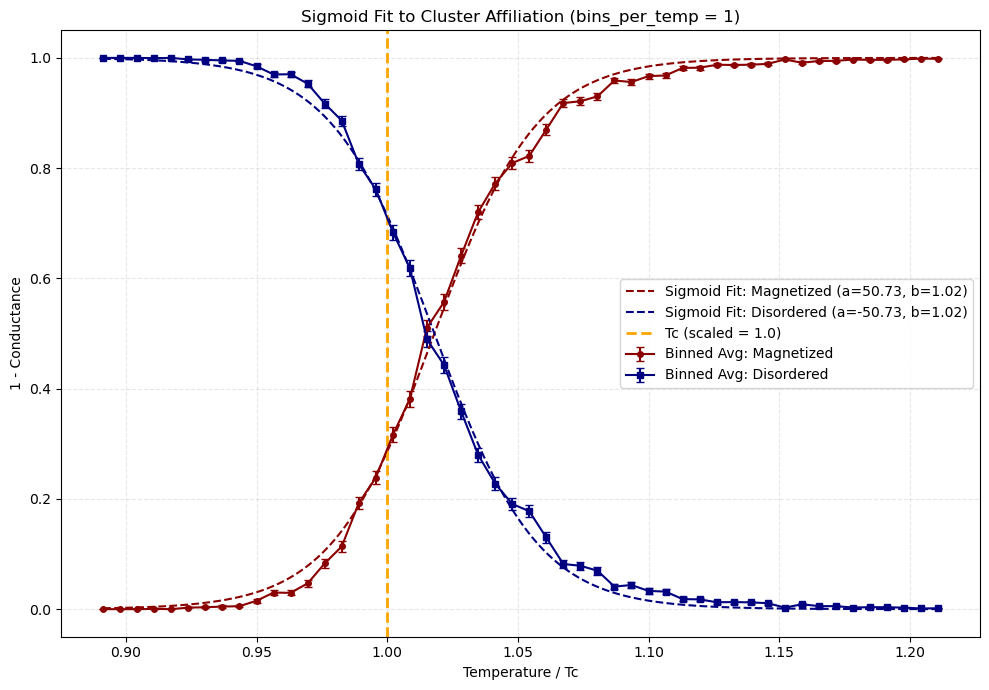

In [37]:
from scipy.optimize import curve_fit

#  Configuration 
Tc = 2.3
bins_per_temp = 1

# Scores
magnetized_score = np.array(magnetized_score)
disordered_score = np.array(disordered_score)

# Compute 1 - conductance scores
y_mag = 1 - magnetized_score
y_dis = 1 - disordered_score

# Bin by temperature labels
unique_temps = np.unique(temps)
binned_temp = []
binned_mag = []
binned_dis = []
binned_err_mag = []
binned_err_dis = []

for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]
    np.random.shuffle(indices)
    sub_bins = np.array_split(indices, bins_per_temp)
    
    for sub in sub_bins:
        if len(sub) > 0:
            binned_temp.append(T / Tc)
            mag_vals = y_mag[sub]
            dis_vals = y_dis[sub]
            binned_mag.append(np.mean(mag_vals))
            binned_dis.append(np.mean(dis_vals))
            binned_err_mag.append(np.std(mag_vals, ddof=1) / np.sqrt(len(mag_vals)))
            binned_err_dis.append(np.std(dis_vals, ddof=1) / np.sqrt(len(dis_vals)))

# Convert to numpy arrays and sort
binned_temp = np.array(binned_temp)
binned_mag = np.array(binned_mag)
binned_dis = np.array(binned_dis)
binned_err_mag = np.array(binned_err_mag)
binned_err_dis = np.array(binned_err_dis)

sort_idx = np.argsort(binned_temp)
binned_temp = binned_temp[sort_idx]
binned_mag = binned_mag[sort_idx]
binned_dis = binned_dis[sort_idx]
binned_err_mag = binned_err_mag[sort_idx]
binned_err_dis = binned_err_dis[sort_idx]

#  Sigmoid fitting 
def sigmoid(x, a, b):
    return 1 / (1 + np.exp(-a * (x - b)))

fit_x = np.linspace(binned_temp.min(), binned_temp.max(), 500)

# Fit to magnetized
popt_mag, _ = curve_fit(sigmoid, binned_temp, binned_mag, p0=[10, 1.0], maxfev=10000)
fit_y_mag = sigmoid(fit_x, *popt_mag)

# Fit to disordered
popt_dis, _ = curve_fit(sigmoid, binned_temp, binned_dis, p0=[-10, 1.0], maxfev=10000)
fit_y_dis = sigmoid(fit_x, *popt_dis)

#  Plot 
plt.figure(figsize=(10, 7))

# Binned data with error bars
plt.errorbar(binned_temp, binned_mag, yerr=binned_err_mag, fmt='-o',
             color='darkred', label='Binned Avg: Magnetized', capsize=3, markersize=4)
plt.errorbar(binned_temp, binned_dis, yerr=binned_err_dis, fmt='-s',
             color='navy', label='Binned Avg: Disordered', capsize=3, markersize=4)

# Sigmoid fits
plt.plot(fit_x, fit_y_mag, '--', color='darkred',
         label=f'Sigmoid Fit: Magnetized (a={popt_mag[0]:.2f}, b={popt_mag[1]:.2f})')
plt.plot(fit_x, fit_y_dis, '--', color='navy',
         label=f'Sigmoid Fit: Disordered (a={popt_dis[0]:.2f}, b={popt_dis[1]:.2f})')

# Tc reference line
plt.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Tc (scaled = 1.0)')

# Labels and formatting
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title(f"Sigmoid Fit to Cluster Affiliation (bins_per_temp = {bins_per_temp})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# # Save result (optional)
# np.savetxt("sigmoid_fits_cluster_affiliation.csv", np.column_stack([
#     binned_temp, binned_mag, binned_err_mag, binned_dis, binned_err_dis
# ]), delimiter=",", header="temp_scaled,magnetized_avg,magnetized_err,disordered_avg,disordered_err", comments="")


Peak derivative at scaled temperature = 1.041


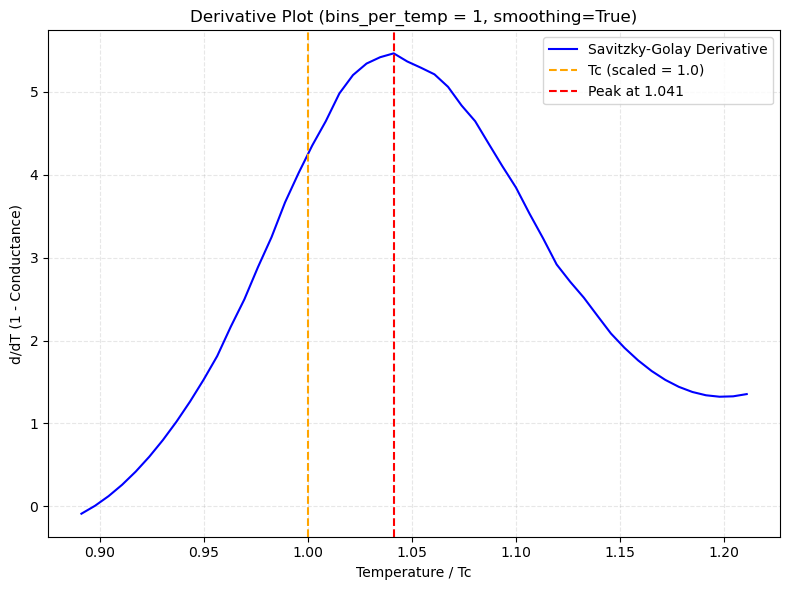

In [36]:
from scipy.signal import savgol_filter

#  Configuration 
bins_per_temp = 1  # Number of bins per temperature
smoothing = True   # Toggle smoothing on/off
y_mag = 1 - magnetized_score  # Inverse magnetization score

# Bin by temperature labels
unique_temps = np.unique(temps)
binned_temp = []
binned_y = []

for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]
    
    np.random.shuffle(indices)
    sub_bins = np.array_split(indices, bins_per_temp)
    
    for sub in sub_bins:
        if len(sub) > 0:
            binned_temp.append(T / Tc)  # Scale temperature
            binned_y.append(np.mean(y_mag[sub]))

binned_temp = np.array(binned_temp)
binned_y = np.array(binned_y)

# Sort by temperature just in case
sort_idx = np.argsort(binned_temp)
binned_temp = binned_temp[sort_idx]
binned_y = binned_y[sort_idx]

#  Compute derivative 
if smoothing:
    window = 21 if len(binned_temp) >= 21 else (len(binned_temp) // 2) * 2 + 1
    delta_T = np.mean(np.diff(binned_temp))
    dy_dT = savgol_filter(binned_y, window_length=window,
                          polyorder=3, deriv=1, delta=delta_T)
    label = 'Savitzky-Golay Derivative'
else:
    dy_dT = np.gradient(binned_y, binned_temp)
    label = 'Raw Numerical Derivative'

# Find peak
peak_idx = np.argmax(np.abs(dy_dT))
peak_temp = binned_temp[peak_idx]
print(f"Peak derivative at scaled temperature = {peak_temp:.3f}")

#  Plot 
plt.figure(figsize=(8, 6))
plt.plot(binned_temp, dy_dT, label=label, color='blue')
plt.axvline(1.0, color='orange', linestyle='--', label='Tc (scaled = 1.0)')
plt.axvline(peak_temp, color='red', linestyle='--', label=f'Peak at {peak_temp:.3f}')
plt.xlabel('Temperature / Tc')
plt.ylabel('d/dT (1 - Conductance)')
plt.title(f'Derivative Plot (bins_per_temp = {bins_per_temp}, smoothing={smoothing})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Save to file
# np.savetxt("16_not_smooth_derivative.csv", np.column_stack([binned_temp, dy_dT]),
#            delimiter=",", header="temp_scaled,dy_dT", comments='')


Peak derivative at scaled temperature = 1.022


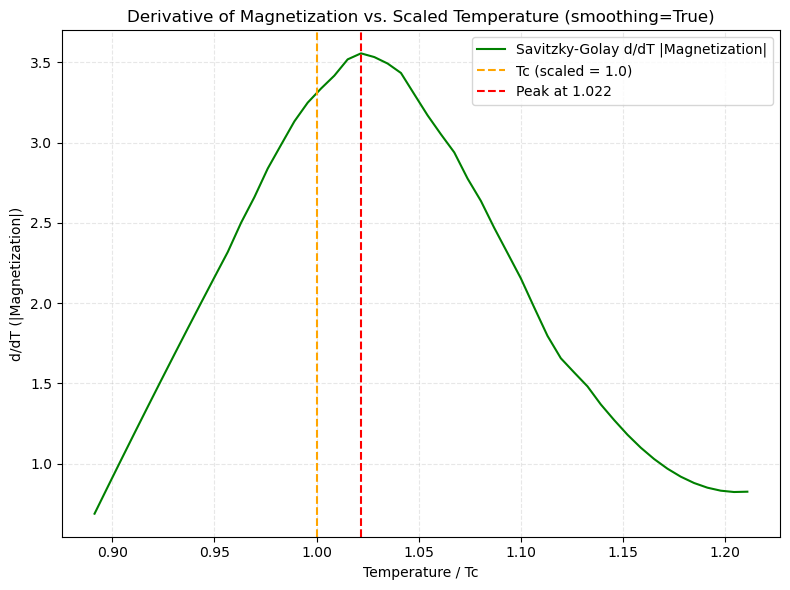

In [34]:
#  Configuration 
L = 16
Tc = 2.3
bins_per_temp = 1  # You can adjust this
smoothing = True   # Toggle smoothing on/off

# Compute normalized magnetization
magnetizations = np.array(combined_temp_mag[:, 1])
magnetizations_norm = np.abs(magnetizations) / (L * L)

# Expand and scale temperatures
temps = np.array(temps)
temps_scaled = temps / Tc

# Bin per temperature label
unique_temps = np.unique(temps)
bin_centers = []
bin_means = []

for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]
    np.random.shuffle(indices)

    sub_bins = np.array_split(indices, bins_per_temp)
    for sub in sub_bins:
        if len(sub) > 0:
            bin_centers.append(T / Tc)
            bin_means.append(np.mean(magnetizations_norm[sub]))

# Convert and sort
bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
sort_idx = np.argsort(bin_centers)
binned_temps = bin_centers[sort_idx]
binned_mag = bin_means[sort_idx]

#  Compute Derivative 
if smoothing:
    window_length = 21 if len(binned_temps) >= 21 else (len(binned_temps) // 2) * 2 + 1
    polyorder = 3
    delta_T = np.mean(np.diff(binned_temps))
    dy_dT = -savgol_filter(binned_mag, window_length=window_length,
                           polyorder=polyorder, deriv=1, delta=delta_T)
    label = 'Savitzky-Golay d/dT |Magnetization|'
else:
    dy_dT = -np.gradient(binned_mag, binned_temps)
    label = 'Raw Numerical d/dT |Magnetization|'

# Peak location
peak_idx = np.argmax(np.abs(dy_dT))
peak_temp = binned_temps[peak_idx]
print(f"Peak derivative at scaled temperature = {peak_temp:.3f}")

#  Plot 
plt.figure(figsize=(8, 6))
plt.plot(binned_temps, dy_dT, label=label, color='green')
plt.axvline(1.0, color='orange', linestyle='--', label='Tc (scaled = 1.0)')
plt.axvline(peak_temp, color='red', linestyle='--', label=f'Peak at {peak_temp:.3f}')
plt.xlabel('Temperature / Tc')
plt.ylabel('d/dT (|Magnetization|)')
plt.title(f'Derivative of Magnetization vs. Scaled Temperature (smoothing={smoothing})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Save results
np.savetxt("magnetization_derivative_not_smooth16.csv",
           np.column_stack([binned_temps, dy_dT]),
           delimiter=",", header="temp_scaled,dMag_dT", comments='')


Peak of sigmoid derivative at scaled temperature = 1.061


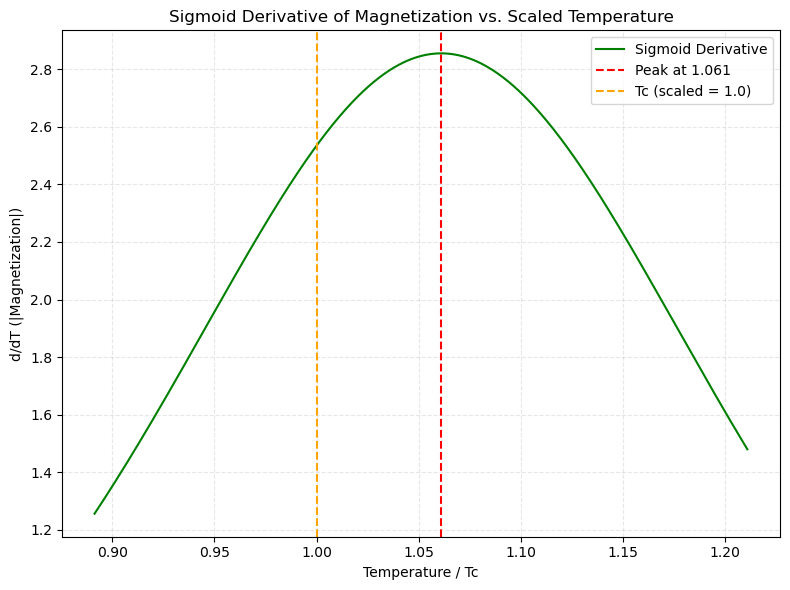

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#  Configuration 
L = 16
Tc = 2.3
bins_per_temp = 1

# Compute normalized magnetization
magnetizations = np.sum(flat_data, axis=1)
magnetizations_norm = np.abs(magnetizations) / (L * L)

# Expand and scale temperatures
temps = np.array(temperature_labels)
temps_scaled = temps / Tc

# Bin per temperature label
unique_temps = np.unique(temps)
bin_centers = []
bin_means = []

for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]
    np.random.shuffle(indices)

    sub_bins = np.array_split(indices, bins_per_temp)
    for sub in sub_bins:
        if len(sub) > 0:
            bin_centers.append(T / Tc)
            bin_means.append(np.mean(magnetizations_norm[sub]))

# Convert and sort
bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
sort_idx = np.argsort(bin_centers)
binned_temps = bin_centers[sort_idx]
binned_mag = bin_means[sort_idx]

#  Sigmoid function and derivative 
def sigmoid(x, a, b):
    return 1 / (1 + np.exp(-a * (x - b)))

def sigmoid_derivative(x, a, b):
    s = sigmoid(x, a, b)
    return a * s * (1 - s)

#  Fit sigmoid 
popt, _ = curve_fit(sigmoid, binned_temps, binned_mag, p0=[10, 1.0], maxfev=10000)
fit_x = np.linspace(binned_temps.min(), binned_temps.max(), 500)
fit_dy_dT = -sigmoid_derivative(fit_x, *popt)

#  Find peak of derivative 
peak_idx = np.argmax(fit_dy_dT)
peak_temp = fit_x[peak_idx]
print(f"Peak of sigmoid derivative at scaled temperature = {peak_temp:.3f}")

#  Plot 
plt.figure(figsize=(8, 6))
plt.plot(fit_x, fit_dy_dT, label='Sigmoid Derivative', color='green')
plt.axvline(peak_temp, color='red', linestyle='--', label=f'Peak at {peak_temp:.3f}')
plt.axvline(1.0, color='orange', linestyle='--', label='Tc (scaled = 1.0)')
plt.xlabel('Temperature / Tc')
plt.ylabel('d/dT (|Magnetization|)')
plt.title('Sigmoid Derivative of Magnetization vs. Scaled Temperature')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# np.savetxt("sigmoid_derivative_mag16.csv",
#            np.column_stack([fit_x, fit_dy_dT]),
#            delimiter=",",
#            header="temp_scaled,sigmoid_derivative",
#            comments='')

